# RFF-MMD Change Point Detection

This notebook implements a sparse-grid change point detector based on the maximum mean discrepancy (MMD) in Random Fourier Feature space. Features are whitened by their regularized covariance, windows are scanned by a greedy dyadic search, and each detection is localised to a single index.

### Imports

Loads the numerical and plotting dependencies and raises the recursion limit required by the recursive search.

In [1]:
import numpy as np
import math
from math import sqrt, log, floor, lgamma
import sys
import matplotlib.pyplot as plt

sys.setrecursionlimit(20000)

### RFF

Defines the Random Fourier Feature map approximating the Gaussian kernel, and the median heuristic used to select the kernel bandwidth.

In [2]:
class RFF:
    """
    Random Fourier Feature map for the Gaussian kernel K(x,y)=exp(-gamma||x-y||^2).

    Draws `rr` random frequencies omega_j ~ N(0, 2*gamma*I) and maps each point
    x to [sin(omega x), cos(omega x)] / sqrt(rr) in R^{2*rr}, so that the
    Euclidean inner product of two feature vectors approximates K(x, y).
    """

    def __init__(self, dd, rr, gamma, seed=0):
        """
        Args:
            dd    (int)   : data dimension (number of columns of X).
            rr    (int)   : number of random features; feature dimension is 2*rr.
            gamma (float) : Gaussian kernel bandwidth parameter.
            seed  (int)   : RNG seed for reproducible frequencies.
        """
        rng = np.random.default_rng(seed)
        self.omega = rng.normal(scale=np.sqrt(2 * gamma), size=(rr, dd))  # (rr, dd)
        self.rr = rr

    def zz(self, xx):
        """
        Map one point to its RFF feature vector.

        Args:
            xx (array, shape (dd,)) : a single data point.
        Returns:
            array, shape (2*rr,) : the feature vector [sin(proj), cos(proj)]/sqrt(rr).
        """
        proj = self.omega @ xx                       # (rr,)
        return np.concatenate([np.sin(proj), np.cos(proj)]) / np.sqrt(self.rr)


def med(XX):
    """
    Median heuristic for the kernel bandwidth.

    Computes H_n = median{ ||X_i - X_j||^2 : i < j }, the typical squared
    pairwise distance. A common choice is then gamma = 1 / H_n.

    Args:
        XX (array, shape (n, d)) : the data points.
    Returns:
        float : H_n, the median squared pairwise distance.
    """
    sq = np.sum((XX[:, None, :] - XX[None, :, :]) ** 2, axis=-1)  # all ||Xi-Xj||^2
    iu = np.triu_indices(XX.shape[0], k=1)           # pairs where i < j
    return np.median(sq[iu])

### Whitening

Computes the whitening matrix: the inverse square root of the feature covariance plus a ridge term. Applying it gives the features identity covariance; the ridge term keeps the matrix invertible.

In [3]:
def whitening_matrix(ZZ, lam):
    """
    W = (Sigma_hat + lam*I)^(-1/2), the matrix that rescales the features so
    that their covariance is the identity.

    Three steps, in order:
        1. Sigma = the covariance of the feature vectors
        2. A     = Sigma + lam * I, the regularization
        3. W     = A^(-1/2), the inverse square root

    Step 3 is done through the symmetric eigendecomposition A = V diag(w) V^T.
    Raising A to the power -1/2 means raising each w to the power -1/2 and
    leaving V alone, which is what (VV * ww**-0.5) @ VV.T computes.

    The regularization in step 2 is not optional: the feature covariance is
    close to singular, so without it step 3 would divide by numbers near zero.

    Args:
        ZZ (array, shape (n, d)) : the feature matrix.
        lam (float) : regularization constant.
    Returns:
        array, shape (d, d) : the whitening matrix.
    """
    nn, dd = ZZ.shape
    Sigma = ZZ.T @ ZZ / nn                       # 1. covariance of the data
    AA = Sigma + lam * np.eye(dd)                # 2. add lam * identity
    ww, VV = np.linalg.eigh(AA)                  # 3. inverse square root
    return (VV * ww ** -0.5) @ VV.T

### Threshold

Computes the detection threshold at significance level `alpha`, and the default regularization `lam = 1 / log(n / W)`:

$$T = \sqrt{2L} + \frac{\max\left(0,\; R\log\log\frac{n}{W} - \log\Gamma\!\left(\frac{R}{2}\right)\right) + \log\dfrac{1}{\log\frac{1}{1-\alpha}}}{\sqrt{2L}}, \qquad L = \log\frac{n}{W}$$

where $n$ is the series length, $W$ the smallest window width, and $R$ the number of random features.

In [4]:
def get_thresh(nn, ww, RR, alpha=0.10):
    """
    Detection threshold at significance level alpha.

        T = sqrt(2L) + [ max(0, R*loglog(n/w) - logGamma(R/2))
                         + log(1/log(1/(1-alpha))) ] / sqrt(2L),  L = log(n/w)

    The alpha term is the log of the RECIPROCAL of log(1/(1-alpha)), which is
    positive and grows as alpha shrinks -- so a smaller alpha raises the
    threshold, the direction a significance level should move.

    The leading term counts windows rather than time points, which is why n is
    divided by w. Both correction pieces sit over the same sqrt(2L).

    The max(0, .) is the auxiliary term. Without it, R*loglog(n/w) can fall
    below logGamma(R/2) and drag the threshold down; clamping at zero stops it.

    Args:
        nn (int) : series length.
        ww (int) : smallest window width.
        RR (int) : number of random features (rr).
        alpha (float) : significance level, 0 < alpha < 1.
    Returns:
        float : the threshold.
    """
    if not 0.0 < alpha < 1.0:
        raise ValueError("alpha is a significance level; 0 < alpha < 1")
    if nn <= ww:
        raise ValueError("n must exceed w")
    return sqrt(2.0 * log(nn / ww)) + (
        max(0.0, RR * log(log(nn / ww)) - lgamma(RR / 2.0))
        + log(1.0 / log(1.0 / (1.0 - alpha)))
    ) / sqrt(2.0 * log(nn / ww))


def default_lam(nn, ww):
    """
    Regularization satisfying lam^-1 >> sqrt(2 log(n/w)).

    Uses the stated example lam^-1 = log(n/w), so lam = 1 / log(n/w).

    Args:
        nn (int) : series length.
        ww (int) : smallest window width.
    Returns:
        float : lam.
    """
    return 1.0 / log(nn / ww)

### Window sizes

Generates the dyadic window widths W, 2W, 4W, ... up to half the series length, with W = n^aa, and enumerates every window position, narrowest first.

In [5]:
def get_window_sizes(nn, WW=None, aa=0.5):
    """
    Dyadic window sizes starting from a chosen minimum W.

    The smallest window is W, then 2W, 4W, and so on:

        size(j) = W * 2^j,   j = 0 .. floor(log2(nn / (2*W)))

    The upper limit on j keeps the largest window at or below nn/2, so every
    window still has room to sit inside the series with both halves present.

    W is chosen rather than fixed at 2. In practice W = nn^aa for some
    0 < aa < 1, which lets the smallest window grow with the series instead of
    staying at a couple of points: with nn = 1000 and aa = 0.5, W = 32.

    Setting W = 2 recovers the earlier behaviour exactly.

    Args:
        nn (int) : series length.
        WW (int or None) : smallest window width. None -> round(nn ** aa).
        aa (float) : exponent used when WW is None; 0 < aa < 1.
    Returns:
        list[int] : window widths, ascending (finest first). Empty if no window
                    of width WW fits with WW <= nn/2.
    """
    if WW is None:
        WW = int(round(nn ** aa))
    WW = max(2, int(WW))
    if WW > nn // 2:
        return []
    jj_max = floor(math.log2(nn / (2 * WW)))
    return [WW * 2 ** jj for jj in range(jj_max + 1)]


def generate_grid(ss, ee, nn, WW=None, aa=0.5):
    """
    Yield all (start, width) windows that fit inside the segment [ss, ee).

    Finest scale first, so a greedy consumer meets the narrowest windows first.

    Args:
        ss (int) : segment left bound (inclusive).
        ee (int) : segment right bound (exclusive).
        nn (int) : full series length (sets the dyadic scale set).
        WW (int or None) : smallest window width; see get_window_sizes.
        aa (float) : exponent used when WW is None.
    Yields:
        (ll, ww) tuples : window start ll and width ww with ll+ww <= ee.
    """
    window_sizes = get_window_sizes(nn, WW, aa)
    for ww in window_sizes:
        for ll in range(ss, ee - ww + 1):
            yield (ll, ww)

### Statistic

Computes the MMD statistic for a window: the scaled distance between the summed feature vectors of its two halves, obtained in constant time from the prefix sum.

In [6]:
def diff_statistic(Y_cumsum, ll, ww):
    """
    Local MMD statistic on the window [ll, ll+ww), split into two halves.

    Y_cumsum is the prefix sum of the RFF feature matrix, so the two half-sums
    are vectors and the statistic is the norm of their difference, scaled:

        ||sum_B - sum_A|| / sqrt(ww) = sqrt(ww)/2 * ||mean_B - mean_A||

    Args:
        Y_cumsum (array, shape (n+1, 2*rr)) : prefix sum of the feature matrix.
        ll (int) : window start index.
        ww (int) : window width.
    Returns:
        float : the (non-negative) MMD statistic for this window; 0 if ww < 2.
    """
    chunk = ww // 2
    if chunk == 0:
        return 0.0
    Y_bar_0 = Y_cumsum[ll + chunk]     - Y_cumsum[ll]            # first half sum
    Y_bar_1 = Y_cumsum[ll + 2 * chunk] - Y_cumsum[ll + chunk]    # second half sum

    numerator = np.linalg.norm(-Y_bar_0 + Y_bar_1)              # MMD (feature space)
    scale = sqrt(ww)
    return numerator / scale

### Search

Scans windows narrowest first. On the first window exceeding the threshold, records it and recurses on the segments to its left and right.

In [7]:
def greedy_interval_search(Y_cumsum, ss, ee, nn, thresh, intervals,
                           WW=None, aa=0.5):
    """
    Recursively find intervals that contain a significant change point.

    Scans the dyadic grid finest-first; on the first window whose statistic
    exceeds `thresh`, records that window as an interval and recurses on the
    left and right sub-segments. Mutates `intervals` in place.

    Args:
        Y_cumsum (array, shape (n+1, 2*rr)) : feature prefix sum.
        ss (int) : current segment left bound (inclusive).
        ee (int) : current segment right bound (exclusive).
        nn (int) : full series length.
        thresh (float) : detection threshold from get_thresh().
        intervals (list) : accumulator; each entry is a dict with
                           "start", "end", "stat".
        WW (int or None) : smallest window width; see get_window_sizes.
        aa (float) : exponent used when WW is None.
    Returns:
        None (results are appended to `intervals`).
    """
    if (ee - ss) < 2:
        return
    detection = False
    for ll, ww in generate_grid(ss, ee, nn, WW, aa):
        stat = diff_statistic(Y_cumsum, ll, ww)
        if abs(stat) > thresh:
            intervals.append({
                "start": ll,
                "end":   ll + ww - 1,
                "stat":  round(float(stat), 4),
            })
            greedy_interval_search(Y_cumsum, ss, ll, nn, thresh, intervals,
                                   WW, aa)
            greedy_interval_search(Y_cumsum, ll + ww - 1, ee, nn, thresh,
                                   intervals, WW, aa)
            detection = True
        if detection:
            break
    return

### Post Processing

Localises the change point within a detected interval by selecting the split that maximises the weighted MMD between the two sides.

In [8]:
def localise(Y_cumsum, tt1, tt2, min_side=1):
    """
    Pin the exact change point inside a detected interval [tt1, tt2).

    Sweeps every split kk and maximises the weighted MMD
    ||mean_A - mean_B|| * sqrt(kk*(mm-kk)/mm), where mm = tt2 - tt1. This is the
    LR change-in-mean statistic generalised to RFF feature space.

    Args:
        Y_cumsum (array, shape (n+1, 2*rr)) : feature prefix sum.
        tt1 (int) : interval left bound (inclusive).
        tt2 (int) : interval right bound (exclusive).
        min_side (int) : minimum points on each side of the split (default 1).
    Returns:
        (cp, stat) : cp = tt1 + best_kk + 1 (first index of the second segment),
                     stat = the weighted MMD at that split.
    """
    mm = tt2 - tt1
    if mm < 2:
        return tt1, 0.0
    best_stat, best_kk = -1.0, mm // 2
    for kk in range(min_side, mm - min_side + 1):
        mean_A = (Y_cumsum[tt1 + kk] - Y_cumsum[tt1]) / kk
        mean_B = (Y_cumsum[tt2]      - Y_cumsum[tt1 + kk]) / (mm - kk)
        stat = np.linalg.norm(mean_A - mean_B) * sqrt(kk * (mm - kk) / mm)
        if stat > best_stat:
            best_stat, best_kk = stat, kk
    return tt1 + best_kk + 1, best_stat

### Pipeline

Prepares the data: selects the bandwidth, applies the feature map, whitens the features, and builds the prefix sum.

In [9]:
def _build_feature_cumsum(XX, rr, gamma, seed, lam):
    """
    Shared preprocessing: coerce input, pick bandwidth, RFF map, whiten, prefix sum.

    The whitening step is the change: after mapping the data into RFF space the
    features are rescaled by W = (Sigma_hat + lam*I)^(-1/2), so their covariance
    is the identity. Everything downstream then works on features of known
    scale, which is what lets the threshold be sqrt(2 log n) with no estimated
    noise level. Nothing else in the algorithm changes -- only how the data is
    looked at.

    Args:
        XX (array, shape (n,) or (n, d)) : input data.
        rr (int) : number of random features.
        gamma (float or None) : kernel bandwidth; if None, uses 1/med(XX).
        seed (int) : RNG seed for the RFF map.
        lam (float) : regularization added to the covariance before whitening.
    Returns:
        XX       (array, shape (n, d)) : the data as a 2-D float array.
        nn       (int)                 : number of points.
        gamma    (float)               : the bandwidth actually used.
        Y_cumsum (array, (n+1, 2*rr))  : prefix sum of the feature matrix.
    """
    XX = np.asarray(XX, dtype=float)
    if XX.ndim == 1:
        XX = XX[:, None]
    nn = XX.shape[0]
    if gamma is None:
        gamma = 1.0 / med(XX)
    rff = RFF(dd=XX.shape[1], rr=rr, gamma=gamma, seed=seed)
    ZZ = np.array([rff.zz(XX[ii]) for ii in range(nn)])
    ZZ = ZZ @ whitening_matrix(ZZ, lam).T        # <-- whiten: Cov(ZZ) becomes I
    Y_cumsum = np.zeros((nn + 1, ZZ.shape[1]))
    np.cumsum(ZZ, axis=0, out=Y_cumsum[1:])
    return XX, nn, gamma, Y_cumsum

### Sparse grid CP

Runs the full detector and returns the change points together with the parameters used.

In [10]:
def detect_sparse(XX, rr=5, gamma=None, seed=42, lam=None,
                  WW=None, aa=0.5, alpha=0.10, RR=None):
    """
    Sparse-grid detector: dyadic greedy search + post-processing.

    Args:
        XX (array, shape (n,) or (n, d)) : input series.
        rr (int) : number of random features. Keep it small relative to n:
                   the covariance is 2*rr by 2*rr and must be estimable.
        gamma (float or None) : kernel bandwidth; None -> median heuristic.
        seed (int) : RNG seed for the RFF map.
        lam (float or None) : regularization; None -> 1/log(n/W), which
                   satisfies lam^-1 >> sqrt(2 log(n/W)).
        WW (int or None) : smallest window width; None -> round(n ** aa).
        aa (float) : exponent setting W when WW is None; 0 < aa < 1.
        alpha (float) : significance level for the threshold, 0 < alpha < 1.
        RR (int or None) : R in the threshold; None -> rr, the number of
                   random features.
    Returns:
        dict with:
            "intervals" : list of dicts, each {"start","end","stat","cp","cp_stat"}.
            "cps"       : list[int], the post-processed change-point indices.
            "thresh"    : float, the detection threshold used.
            "lam"       : float, the regularization used.
            "gamma"     : float, the bandwidth used.
    """
    XX = np.asarray(XX, dtype=float)
    if XX.ndim == 1:
        XX = XX[:, None]
    nn = XX.shape[0]
    sizes = get_window_sizes(nn, WW, aa)
    if not sizes:
        raise ValueError("no window fits: W is larger than n/2")
    ww0 = sizes[0]                                   # smallest window = omega
    if lam is None:
        lam = default_lam(nn, ww0)
    if RR is None:
        RR = rr                                      # R is the number of RFF
    XX, nn, gamma, Y_cumsum = _build_feature_cumsum(XX, rr, gamma, seed, lam)
    thresh = get_thresh(nn, ww0, RR, alpha)

    intervals = []
    greedy_interval_search(Y_cumsum, 0, nn, nn, thresh, intervals, WW, aa)
    intervals = sorted(intervals, key=lambda x: x["start"])

    for iv in intervals:                                   # post-process each
        iv["cp"], cp_stat = localise(Y_cumsum, iv["start"], iv["end"] + 1)
        iv["cp_stat"] = round(cp_stat, 4)

    return {"intervals": intervals, "cps": [iv["cp"] for iv in intervals],
            "thresh": round(thresh, 4), "lam": round(float(lam), 6),
            "gamma": round(float(gamma), 6), "W": ww0,
            "alpha": alpha, "R": RR}

### Data generation

Generates the two synthetic benchmark scenarios. Scenario 1 changes in mean and variance; Scenario 2 holds mean and variance fixed and changes only the shape of the distribution.

In [11]:
# Fixed segmentation from Arlot, Celisse & Harchaoui (2019), Section 6.1:
# n = 1000, 11 segments, 10 change points.
tau_star = [500, 1000, 2000]
_N = 3000                      # series length
_D = 1                         # number of dimensions per observation
_bounds = [0] + tau_star + [_N]

# Distribution names, index-aligned with the draw() branches below.
S1_NAMES = ["Bi(10,0.2)", "Neg_Bi(3,0.7)", "Hyper(10,5,2)", "Normal(2.5,0.25)",
            "gamma(0.5,5)", "Weibull(5,2)", "Pareto(1.5,3)"]
S2_NAMES = ["Bernoulli(0.5)", "Normal(0.5,0.25)", "Exp(0.5)"]


def _labels(n_dists, rng):
    """
    Random segment labels following the paper's selection rule.

    S_1 is uniform over {0..n_dists-1}; each S_{l+1} is uniform over that set
    minus S_l, so consecutive segments never share a distribution.

    Args:
        n_dists (int) : number of candidate distributions.
        rng (Generator) : a numpy random generator.
    Returns:
        list[int] : one distribution index per segment.
    """
    out = [rng.integers(n_dists)]
    for _ in range(1, len(_bounds) - 1):
        out.append(rng.choice([d for d in range(n_dists) if d != out[-1]]))
    return out


def make_scenario1(seed=0):
    """
    Scenario 1: real-valued data with changing (mean, variance).

    Seven distributions (Table B.1), one drawn per segment. The mean usually
    shifts across boundaries -> the easier case.

    Args:
        seed (int) : RNG seed (fixes which distribution lands in each segment).
    Returns:
        X         (array, shape (_N, _D)) : the generated series. Each of the
                   _D coordinates is an independent draw from that segment's
                   distribution, using the same parameters, so all coordinates
                   change at the same points.
        tau_star  (list[int])             : the true change points.
        seg_names (list[str])             : distribution name per segment.
    """
    rng = np.random.default_rng(seed)
    labels = _labels(7, rng)

    def draw(dist, size):
        if dist == 0: return rng.binomial(10, 0.2, size).astype(float)
        if dist == 1: return rng.negative_binomial(3, 0.7, size).astype(float)
        if dist == 2: return rng.hypergeometric(5, 5, 2, size).astype(float)
        if dist == 3: return rng.normal(2.5, 0.5, size)
        if dist == 4: return rng.gamma(0.5, 5.0, size)
        if dist == 5: return 5.0 * rng.weibull(2.0, size)
        if dist == 6: return 1.5 * (1.0 + rng.pareto(3.0, size))

    xx = np.empty((_N, _D))
    for s, e, lab in zip(_bounds[:-1], _bounds[1:], labels):
        xx[s:e] = draw(lab, (e - s, _D))          # (rows, dimensions)
    seg_names = [S1_NAMES[d] for d in labels]
    return xx, list(tau_star), seg_names


def make_scenario2(seed=0):
    """
    Scenario 2: constant mean 0.5 and variance 0.25; only the shape changes.

    Three distributions (Bernoulli, Gaussian, exponential), one per segment,
    all sharing mean 0.5 and variance 0.25 -> the hard, shape-only case.

    Args:
        seed (int) : RNG seed (fixes which distribution lands in each segment).
    Returns:
        X         (array, shape (_N, _D)) : the generated series.
        tau_star  (list[int])             : the true change points.
        seg_names (list[str])             : distribution name per segment.
    """
    rng = np.random.default_rng(seed)
    labels = _labels(3, rng)

    def draw(dist, size):
        if dist == 0: return rng.binomial(1, 0.5, size).astype(float)
        if dist == 1: return rng.normal(0.5, 0.5, size)
        if dist == 2: return rng.exponential(0.5, size)

    xx = np.empty((_N, _D))
    for s, e, lab in zip(_bounds[:-1], _bounds[1:], labels):
        xx[s:e] = draw(lab, (e - s, _D))          # (rows, dimensions)
    seg_names = [S2_NAMES[d] for d in labels]
    return xx, list(tau_star), seg_names

### Settings

Sets the number of random features, the significance level, and the regularization for the run below.

In [12]:
rr = 100        # number of random features; small relative to n
alpha = 0.1   # significance level for the threshold; 0 < alpha < 1
lam = None     # regularization added to the covariance before whitening.
               # None uses 1/log(n/W), which satisfies
               # lam^-1 >> sqrt(2 log(n/W)).

### Graph

Runs the detector on both scenarios and plots the detected change points against the true ones.

Scenario 1: true=[500, 1000, 2000]
   shape=(3000, 1)  W=55  R=100  alpha=0.1
   lam=0.25006  thresh=3.6238
   segments: Bi(10,0.2) -> Normal(2.5,0.25) -> gamma(0.5,5) -> Bi(10,0.2)
   sparse cps (3): [497, 1001, 2001]


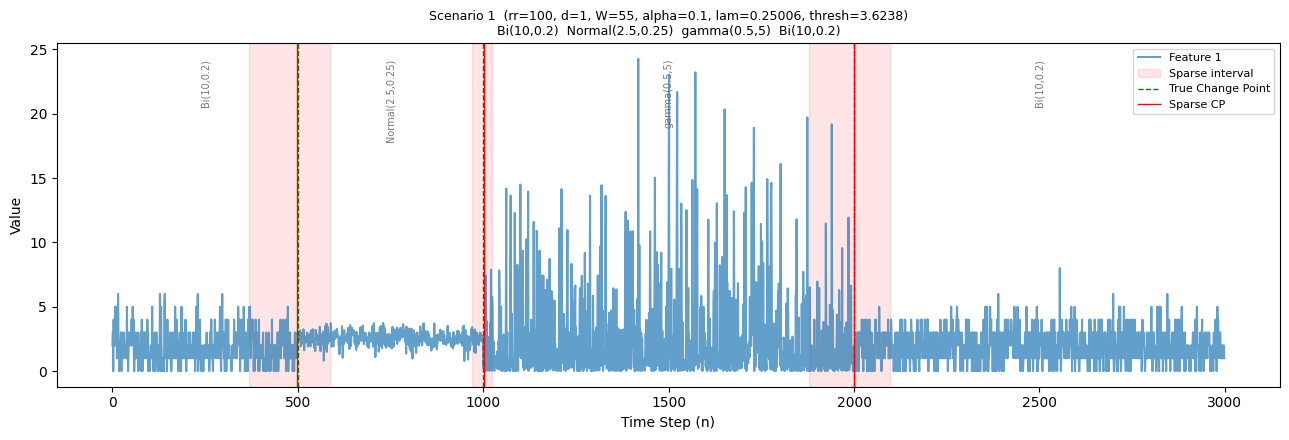

Scenario 2: true=[500, 1000, 2000]
   shape=(3000, 1)  W=55  R=100  alpha=0.1
   lam=0.25006  thresh=3.6238
   segments: Bernoulli(0.5) -> Normal(0.5,0.25) -> Exp(0.5) -> Bernoulli(0.5)
   sparse cps (4): [500, 1064, 1999, 2202]


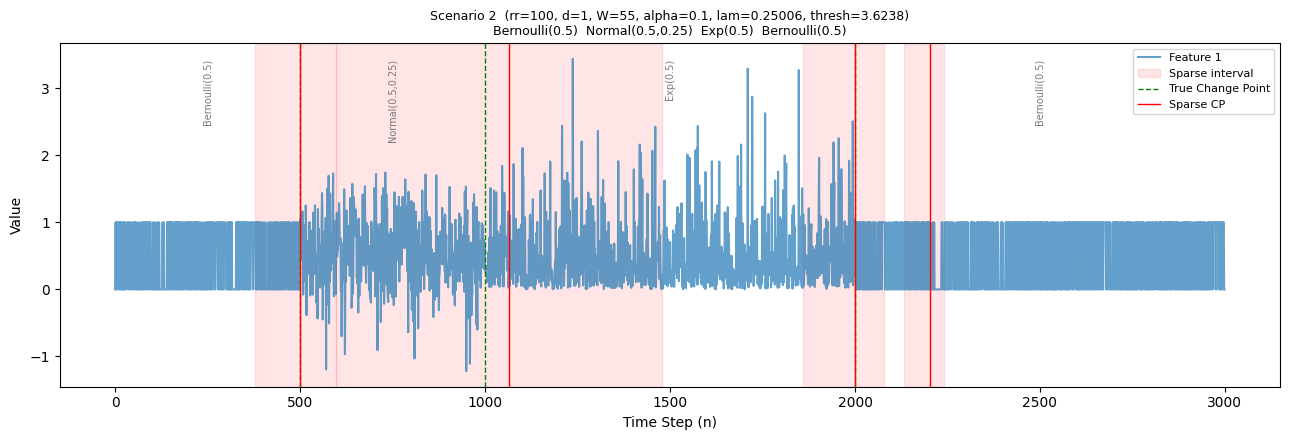

In [13]:
for scen, gen in [("Scenario 1", make_scenario1),
                  ("Scenario 2", make_scenario2)]:
    X, true_cps, seg_names = gen(seed=800)

    sparse = detect_sparse(X, rr=rr, seed=42, lam=lam, alpha=alpha)
    sparse_cps = sorted(sparse["cps"])

    print(f"{scen}: true={true_cps}")
    print(f"   shape={X.shape}  W={sparse['W']}  R={sparse['R']}  alpha={alpha}")
    print(f"   lam={sparse['lam']}  thresh={sparse['thresh']}")
    print(f"   segments: {' -> '.join(seg_names)}")
    print(f"   sparse cps ({len(sparse_cps)}): {sparse_cps}")

    plt.figure(figsize=(13, 4.5))
    for jj in range(X.shape[1]):
        plt.plot(X[:, jj], label=f'Feature {jj + 1}', alpha=0.7)

    # shaded detection intervals (behind the CP lines)
    for i, iv in enumerate(sparse["intervals"]):
        plt.axvspan(iv["start"], iv["end"], color='r', alpha=0.10,
                    label='Sparse interval' if i == 0 else None)

    for i, t in enumerate(true_cps):
        plt.axvline(x=t, color='g', linestyle='--', lw=1,
                    label='True Change Point' if i == 0 else None)
    for i, c in enumerate(sparse_cps):
        plt.axvline(x=c, color='r', linestyle='-', lw=1,
                    label='Sparse CP' if i == 0 else None)

    edges = [0] + true_cps + [len(X)]
    ymax = X.max()
    for s, e, name in zip(edges[:-1], edges[1:], seg_names):
        plt.text((s + e) / 2, ymax, name, rotation=90, ha='center',
                 va='top', fontsize=7, color='dimgray', alpha=0.9)

    plt.title(f"{scen}  (rr={rr}, d={_D}, W={sparse['W']}, alpha={alpha}, "
              f"lam={sparse['lam']}, thresh={sparse['thresh']})\n"
              + "  ".join(seg_names), fontsize=9)
    plt.xlabel("Time Step (n)")
    plt.ylabel("Value")
    plt.legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()